# Behind the Curve — a quantitative teardown 🔬
### Taylor (1993) gap · real-time gaps · Stambaugh · simulation null · timing race

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The Taylor gap
`i − i*` is built from **final-vintage** quarterly US macro with two real-time output gaps and a
one-quarter release lag, then tested as a predictor of next-quarter equity excess returns and
AAA-yield changes. Because the gap is highly persistent, the inference is the Stambaugh (1999)
correction and a simulation null with jointly resampled innovations — which also delivers
overlap-correct p-values at 4 and 8 quarters.

> ⚠️ **Not investment advice.** All code cells run on the real tapes (SHA-pinned, shipped inside
> statsmodels and arch); the numbers quoted in prose mirror [`docs/results.md`](../docs/results.md)
> (as-of 2009-12-31, fingerprint `09aa8b5c4d4e`). §8 is the synthetic control —
> machinery proof, never market evidence.
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 80
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from taylorgap import data, strategy as st

## Beat 0 · Verdict (real tape)

| Axis | Stamp | Decisive numbers |
|---|---|---|
| **Signal** | None | equity slope +0.14%/pt, NW *t* +0.43, Stambaugh *t* +0.47, sim p 0.69; unemployment gap +0.19%/pt (*t* +0.55); bond Δy slope -0.037 pp/pt, *t* -2.04, sim p 0.06 |
| **Tradability** | Mirage | net Sharpe 0.12 vs B&H 0.28, ΔSR -0.17 [-0.41, +0.03]; timing α -1.86% (*t* -1.22) |

> **In one sentence:** Being behind the curve bought stocks no tailwind — the real-time Taylor gap's one-quarter equity slope is +0.14% per point (simulation p = 0.69), only the bond headwind comes close (p = 0.06), and the timing rule's net Sharpe was 0.12 against 0.28 for buy-and-hold, on final-vintage data that flatter it.

## 1 · The claim and the hypotheses

Taylor (1993): `i* = r* + π + 0.5(π − π*) + 0.5·gap`, `r* = π* = 2`. Taylor gap `TG = i − i*`.
The claim predicts, for `y[t+1] = a + b·TG[t] + e`:

- **H₁ (equity):** `b < 0` for the equity excess return — behind the curve, stocks do better.
- **H₂ (bonds):** `b < 0` for the AAA-yield change — behind the curve, yields rise.
- **H₃ (horizon):** the same at 4 and 8 quarters (cumulative), with overlap-correct inference.
- **H₄ (trade):** stocks-when-behind beats buy-and-hold on net excess Sharpe.

Pre-registered bar (`strategy.verdict`): a leg is real with the claim's sign, robust |*t*| ≥ 2
**and** two-sided simulation-null p < 0.05 (equity: Stambaugh-corrected *t*, and the
unemployment-gap version must agree in sign).

## 2 · Construction

- `i`: quarterly-average 3-month T-bill (policy-rate proxy; not lagged — a market price).
- `π`: four-quarter CPI inflation, **lagged one quarter**.
- Gap (a): one-sided HP (λ 1600) on 100·ln real GDP, re-run every quarter on data to date
  (≥ 40 quarters), endpoint kept, **lagged one quarter**.
- Gap (b): `−2 × (u − trailing 40-quarter mean u)`, **lagged one quarter**.
- Hindsight gap: two-sided full-sample HP — for comparison only.

In [2]:
p = st.real_panel()
print(f"real tape: signals {p.index[0].date()} -> {p['tgap_hp'].dropna().index[-1].date()}, "
      f"{int(p['tgap_hp'].notna().sum())} quarters | as-of {data.AS_OF}")
print("macro: statsmodels macrodata, FINAL VINTAGE | equity: Fama-French TOTAL return | "
      "bond: Moody's AAA yield")

cols = ["i", "pi", "gap_hp", "gap_u", "gap_hind", "tgap_hp", "tgap_u", "tgap_hind"]
p[cols].describe().T[["mean", "std", "min", "max"]].round(2)

real tape: signals 1969-03-31 -> 2009-09-30, 163 quarters | as-of 2009-12-31
macro: statsmodels macrodata, FINAL VINTAGE | equity: Fama-French TOTAL return | bond: Moody's AAA yield


,mean,std,min,max
i,5.7100,2.9600,0.1200,15.3300
pi,4.4400,2.8300,-1.9100,13.6200
gap_hp,-0.2200,1.6400,-4.0300,3.8200
gap_u,-0.2900,2.8200,-8.4400,4.2300
gap_hind,-0.0300,1.5900,-4.7600,3.8300
tgap_hp,-1.8800,2.8800,-12.9700,4.1900
tgap_u,-1.8700,2.9300,-13.5000,7.3200
tgap_hind,-1.9800,3.1800,-14.5700,5.9300


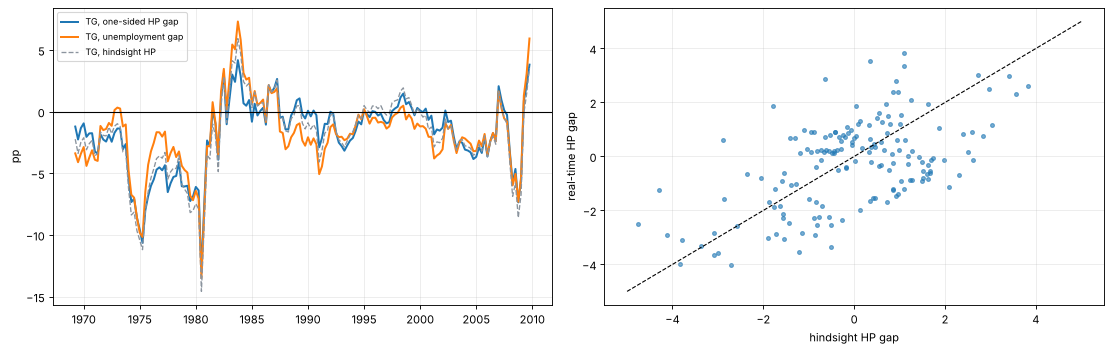

{'corr_gap_hp_hind': 0.5548215072823168,
 'corr_gap_u_hind': 0.6345302212114369,
 'corr_gap_hp_u': 0.2816042079458707,
 'mean_abs_gap_rev': 1.2815727875796246,
 'sign_agree_tgap_hp_hind': 0.901840490797546,
 'sign_agree_tgap_hp_u': 0.852760736196319,
 'share_behind_hp': 0.7300613496932515,
 'share_behind_u': 0.803680981595092}

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(p.index, p["tgap_hp"], lw=1.8, label="TG, one-sided HP gap")
axes[0].plot(p.index, p["tgap_u"], lw=1.8, label="TG, unemployment gap")
axes[0].plot(p.index, p["tgap_hind"], lw=1.2, ls="--", color="#8b949e", label="TG, hindsight HP")
axes[0].axhline(0, color="k", lw=1); axes[0].legend(fontsize=8); axes[0].set_ylabel("pp")
axes[1].scatter(p["gap_hind"], p["gap_hp"], s=12, alpha=0.6)
lim = [-5, 5]; axes[1].plot(lim, lim, "k--", lw=1)
axes[1].set_xlabel("hindsight HP gap"); axes[1].set_ylabel("real-time HP gap")
plt.tight_layout(); plt.show()
st.gap_agreement(p)

> 💡 **In plain words.** The real-time gap and the historian's gap agree only loosely
> (correlation 0.55, average gap 1.28 points apart) — and this is just the
> *filter's* end-point problem. Orphanides (2001) showed the bigger problem is *data revision*,
> which final-vintage data cannot show. Everything here is an upper bound on what was knowable.

## 3 · One-quarter predictive regressions (Newey-West, 4 lags)

In [4]:
rows = []
for sig in ("tgap_hp", "tgap_u", "tgap_hind"):
    for tgt in ("eq_xs", "d_aaa", "bond_xs"):
        r = st.predictive_regression(p, sig, tgt, 1)
        rows.append({"signal": sig, "target": tgt, "slope": r["slope"], "t_NW": r["t"],
                     "R2": r["r2"], "n": r["n"]})
pd.DataFrame(rows).set_index(["signal", "target"]).round(4)

slope    t_NW     R2    n
signal    target                             
tgap_hp   eq_xs    0.0014  0.4340 0.0021  163
          d_aaa   -0.0369 -2.0433 0.0366  163
          bond_xs  0.0031  2.0521 0.0325  163
tgap_u    eq_xs    0.0019  0.5512 0.0037  163
          d_aaa   -0.0358 -1.8256 0.0357  163
          bond_xs  0.0031  1.9529 0.0337  163
tgap_hind eq_xs    0.0023  0.7443 0.0067  163
          d_aaa   -0.0354 -2.0642 0.0408  163
          bond_xs  0.0030  2.1248 0.0374  163

> 💡 **In plain words.** The claim needs negative slopes on `eq_xs` and `d_aaa`. Equities:
> positive and tiny, under all three gaps — even the look-ahead one. Bonds: the right sign,
> *t* ≈ −2. (`bond_xs` is the approximate bond return — its positive slope is the same fact seen
> from the price side.)

## 4 · Persistence and the Stambaugh correction

In [5]:
rows = []
for sig in ("tgap_hp", "tgap_u"):
    for tgt in ("eq_xs", "d_aaa"):
        s = st.stambaugh_correction(p, sig, tgt)
        rows.append({"signal": sig, "target": tgt, **{k: s[k] for k in
                     ("rho", "rho_c", "corr_uv", "slope", "bias", "slope_c", "t", "t_c")}})
pd.DataFrame(rows).set_index(["signal", "target"]).round(4)

rho  rho_c  corr_uv   slope    bias  slope_c       t     t_c
signal  target                                                                
tgap_hp eq_xs  0.8594 0.8813   0.0777  0.0014 -0.0001   0.0015  0.4340  0.4650
        d_aaa  0.8594 0.8813   0.3128 -0.0369 -0.0025  -0.0344 -2.0433 -1.9047
tgap_u  eq_xs  0.8578 0.8798   0.1148  0.0019 -0.0001   0.0020  0.5512  0.5939
        d_aaa  0.8578 0.8798   0.2599 -0.0358 -0.0020  -0.0338 -1.8256 -1.7244

`E[b̂ − b] = γ·E[ρ̂ − ρ]`, `γ = cov(u,v)/var(v)`, `E[ρ̂ − ρ] ≈ −(1+3ρ)/T`. The equity innovation
correlation is small, so the bias is negligible; for bonds, rate shocks move the gap and the long
yield together (corr(u,v) ≈ +0.3), which biases the slope *toward* the claim — the correction
shades the bond *t* toward zero.

## 5 · The simulation null — and long horizons with overlap

In [6]:
sims = {}
for sig in ("tgap_hp", "tgap_u"):
    for tgt in ("eq_xs", "d_aaa"):
        sims[(sig, tgt)] = st.simulation_null(p, sig, tgt, n_sim=2000)
rows = []
for (sig, tgt), sm in sims.items():
    for h in st.HORIZONS:
        d = sm[h]
        rows.append({"signal": sig, "target": tgt, "h": h, "slope": d["slope"], "t_NW": d["t"],
                     "null_2.5%": d["null_t_q"][0], "null_97.5%": d["null_t_q"][2],
                     "p_two": d["p_two"], "p_claim": d["p_claim"]})
spec = pd.DataFrame(rows).set_index(["signal", "target", "h"])
spec.round(3)

slope    t_NW  null_2.5%  null_97.5%  p_two  p_claim
signal  target h                                                       
tgap_hp eq_xs  1  0.0010  0.4340    -2.2960      2.1360 0.6780   0.6590
               4 -0.0000 -0.0710    -2.5170      2.4730 0.9460   0.4820
               8 -0.0010 -0.1390    -3.0560      2.8690 0.9140   0.4660
        d_aaa  1 -0.0370 -2.0430    -2.3390      1.9410 0.0610   0.0400
               4 -0.1240 -1.8740    -2.8420      2.3390 0.1410   0.0880
               8 -0.2470 -2.0450    -3.5130      2.6970 0.1580   0.1080
tgap_u  eq_xs  1  0.0020  0.5510    -2.2510      2.1500 0.5980   0.7080
               4 -0.0000 -0.0560    -2.6360      2.5020 0.9590   0.4920
               8 -0.0010 -0.0860    -3.1100      2.9860 0.9460   0.4900
        d_aaa  1 -0.0360 -1.8260    -2.2680      1.8590 0.0820   0.0530
               4 -0.1150 -1.7160    -2.8040      2.3630 0.1720   0.1040
               8 -0.2000 -1.7690    -3.3090      2.6180 0.2200   0.1410

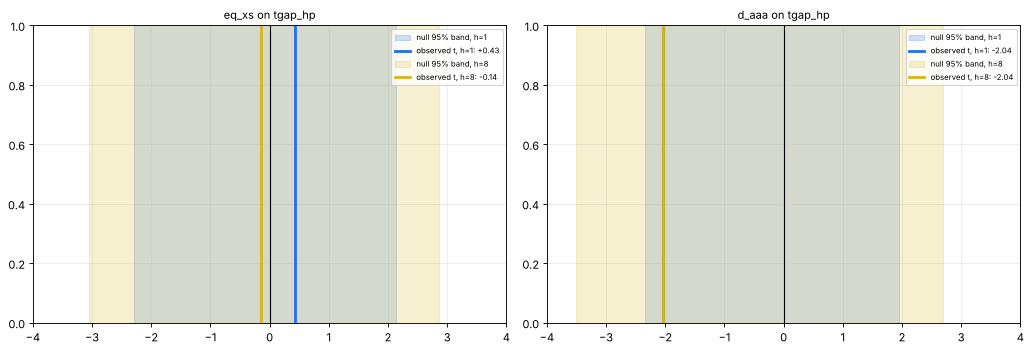

In [7]:
# the null t-bands at h = 1 and h = 8 against the observed t: the overlap effect
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (sig, tgt) in zip(axes, [("tgap_hp", "eq_xs"), ("tgap_hp", "d_aaa")]):
    sm = sims[(sig, tgt)]
    for h, c in ((1, "#1f6feb"), (8, "#dab617")):
        lo, med, hi = sm[h]["null_t_q"]
        ax.axvspan(lo, hi, color=c, alpha=0.2, label=f"null 95% band, h={h}")
        ax.axvline(sm[h]["t"], color=c, lw=2.5, label=f"observed t, h={h}: {sm[h]['t']:+.2f}")
    ax.axvline(0, color="k", lw=1)
    ax.set_title(f"{tgt} on {sig}", fontsize=10); ax.legend(fontsize=7); ax.set_xlim(-4, 4)
plt.tight_layout(); plt.show()

> 💡 **In plain words.** The shaded bands are where the *t*-statistic lands by pure luck
> when the gap predicts nothing but is as sticky as the real one. At 8 quarters the band is far
> wider than ±2 — overlapping returns make long-horizon *t*s look impressive for free. The
> observed equity *t*s sit in the middle of the band. The bond *t* at one quarter (-2.04)
> sits at the edge: p = 0.06 two-sided, 0.04 one-sided.

## 6 · Behind vs ahead, and the regime split (1987Q3)

In [8]:
rows = []
for sig in ("tgap_hp", "tgap_u"):
    for tgt in ("eq_xs", "d_aaa"):
        c = st.conditional_means(p, sig, tgt); r = st.regime_split(p, sig, tgt)
        rows.append({"signal": sig, "target": tgt, "mean_behind": c["mean_behind"],
                     "mean_ahead": c["mean_ahead"], "t_diff": c["t_diff"],
                     "slope_pre": r["slope_pre"], "t_pre": r["t_pre"],
                     "slope_post": r["slope_post"], "t_post": r["t_post"],
                     "t_interaction": r["t_diff"]})
pd.DataFrame(rows).set_index(["signal", "target"]).round(4)

mean_behind  mean_ahead  t_diff  slope_pre   t_pre  \
signal  target                                                       
tgap_hp eq_xs        0.0064      0.0302 -1.3887    -0.0017 -0.5326   
        d_aaa        0.0182     -0.0852  0.9130    -0.0467 -1.8478   
tgap_u  eq_xs        0.0090      0.0282 -0.9368    -0.0011 -0.3557   
        d_aaa        0.0179     -0.1228  1.0470    -0.0463 -1.9340   

                slope_post  t_post  t_interaction  
signal  target                                     
tgap_hp eq_xs       0.0104  1.3679         1.4689  
        d_aaa       0.0039  0.2769         1.7539  
tgap_u  eq_xs       0.0131  1.9682         1.9408  
        d_aaa       0.0094  0.7535         2.0732

> 💡 **In plain words.** Whatever bond effect there is belongs to the pre-Greenspan era of
> high and volatile inflation. Four interaction tests were run; one nominal *t* ≈ 2 among four is
> roughly what chance delivers, so we report it as a lead, not a finding.

## 7 · Could you trade it?

`pos[t+1] = 1{TG[t] < 0}` (one shift, applied once; the macro inside TG is already a quarter
old). 10 bp one-way × traded NAV per switch. Excess-of-cash Sharpe race against buy-and-hold;
circular block bootstrap (8 quarters) on the Sharpe difference.

In [9]:
rows = []
for sig in ("tgap_hp", "tgap_u", "tgap_hp_dm", "tgap_u_dm"):
    bt = st.timing_backtest(p, sig, 10.0)
    s = st.backtest_summary(bt)
    b = st.sharpe_diff_bootstrap(bt["strat_xs_net"].to_numpy(), bt["bh_xs"].to_numpy())
    rows.append({"signal": sig, "invested": s["share_invested"],
                 "switches/yr": s["switches_per_year"], "SR gross": s["sr_gross"],
                 "SR net": s["sr_net"], "SR B&H": s["sr_bh"], "dSR": s["sr_diff_net"],
                 "CI lo": b["ci_lo"], "CI hi": b["ci_hi"], "p(H1: dSR>0)": b["p_one_sided"],
                 "alpha/yr": s["alpha_ann"], "alpha t": s["alpha_t"]})
pd.DataFrame(rows).set_index("signal").round(3)

,invested,switches/yr,SR gross,SR net,SR B&H,dSR,CI lo,CI hi,p(H1: dSR>0),alpha/yr,alpha t
signal,,,,,,,,,,,
tgap_hp,0.7300,0.8830,0.1210,0.1160,0.2830,-0.1670,-0.4060,0.0300,0.9270,-0.0190,-1.2230
tgap_u,0.8040,0.3930,0.1810,0.1790,0.2830,-0.1040,-0.2940,0.0510,0.8760,-0.0110,-0.7750
tgap_hp_dm,0.3780,0.5130,0.1660,0.1610,0.3220,-0.1610,-0.4740,0.1630,0.8320,-0.0050,-0.2790
tgap_u_dm,0.3910,0.6670,0.0800,0.0740,0.3220,-0.2480,-0.5410,0.0320,0.9520,-0.0180,-1.1270


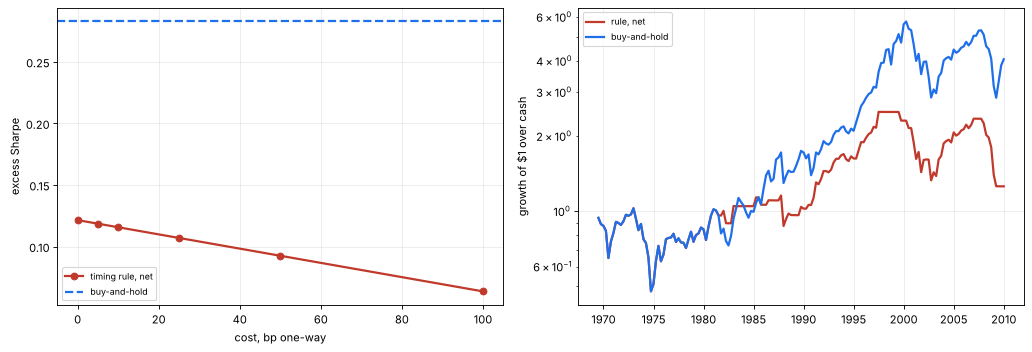

,sr_net,sr_bh,ann_xs_net,ann_xs_bh
cost_bp,,,,
0,0.1210,0.2830,0.0190,0.0510
5,0.1190,0.2830,0.0180,0.0510
10,0.1160,0.2830,0.0180,0.0510
25,0.1070,0.2830,0.0160,0.0510
50,0.0920,0.2830,0.0140,0.0510
100,0.0640,0.2830,0.0100,0.0510


In [10]:
sw = st.cost_sweep(p, "tgap_hp")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(sw.index, sw["sr_net"], "o-", color="#c0392b", lw=2, label="timing rule, net")
axes[0].axhline(sw["sr_bh"].iloc[0], color="#1f6feb", lw=2, ls="--", label="buy-and-hold")
axes[0].set_xlabel("cost, bp one-way"); axes[0].set_ylabel("excess Sharpe"); axes[0].legend(fontsize=8)
bt = st.timing_backtest(p, "tgap_hp", 10.0)
axes[1].plot(bt.index, (1 + bt["strat_xs_net"]).cumprod(), color="#c0392b", lw=2, label="rule, net")
axes[1].plot(bt.index, (1 + bt["bh_xs"]).cumprod(), color="#1f6feb", lw=2, label="buy-and-hold")
axes[1].set_yscale("log"); axes[1].legend(fontsize=8); axes[1].set_ylabel("growth of $1 over cash")
plt.tight_layout(); plt.show()
sw.round(3)

> 💡 **In plain words.** The rule is already behind buy-and-hold *before* costs, so the
> cost line only makes it worse. Net Sharpe 0.12 vs 0.28; the bootstrap interval
> on the difference, [-0.41, +0.03], never favours the rule meaningfully. Demeaning the gap in real
> time (to fix the T-bill/fed-funds level offset) does not rescue it.

## 8 · Synthetic control — machinery proof, not market evidence

Same pipeline on `data.synthetic_quarterly`: an AR(1) gap (ρ 0.92), innovation correlation
−0.4 with returns, a planted slope `b = −0.012` per point at strength 1, and the matched null at
strength 0. If the harness could not find the plant, the real-tape null would mean nothing.

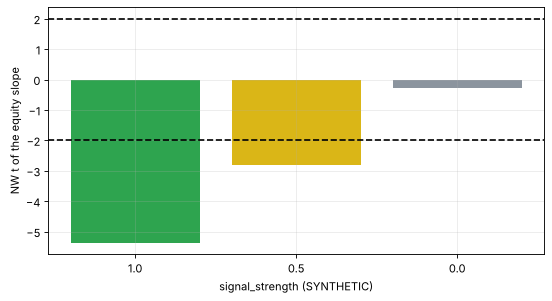

,planted b,b hat,t,p sim,p sim h=8,bond t,bond p,dSR net
strength,,,,,,,,
1.0000,-0.0120,-0.0127,-5.3647,0.0000,0.0140,-5.2255,0.0000,0.3985
0.5000,-0.0060,-0.0067,-2.8255,0.0170,0.1570,-2.8992,0.0080,0.1113
0.0000,-0.0000,-0.0007,-0.2863,0.8020,0.6720,-0.5330,0.5940,-0.1960


In [11]:
rows = []
for s_ in (1.0, 0.5, 0.0):
    w, truth = data.synthetic_quarterly(n_quarters=163, signal_strength=s_)
    sm = st.simulation_null(w, "tgap", "eq_xs", n_sim=1000)
    sb = st.simulation_null(w, "tgap", "d_aaa", n_sim=1000)
    tr = st.backtest_summary(st.timing_backtest(w, "tgap", 10.0))
    rows.append({"strength": s_, "planted b": truth["beta_eq"], "b hat": sm[1]["slope"],
                 "t": sm[1]["t"], "p sim": sm[1]["p_two"], "p sim h=8": sm[8]["p_two"],
                 "bond t": sb[1]["t"], "bond p": sb[1]["p_two"], "dSR net": tr["sr_diff_net"]})
ctrl = pd.DataFrame(rows).set_index("strength")
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(s) for s in ctrl.index], ctrl["t"], color=["#2ea44f", "#dab617", "#8b949e"])
ax.axhline(-2, color="k", ls="--", lw=1.5); ax.axhline(2, color="k", ls="--", lw=1.5)
ax.set_xlabel("signal_strength (SYNTHETIC)"); ax.set_ylabel("NW t of the equity slope")
plt.show()
ctrl.round(4)

## 9 · The verdict (pre-registered rule, applied)

**Signal: None.** Neither leg clears the bar. Equities: wrong sign, *t* +0.43,
sim p 0.69, and the same under the unemployment gap and at 4 and 8 quarters. Bonds: the
claimed sign, *t* -2.04, sim p 0.06 — the nearest miss, concentrated before
1987. None of the twelve specifications clears a two-sided 5% simulation null.

**Tradability: Mirage.** Net excess Sharpe 0.12 vs 0.28; timing alpha
-1.86% a year (*t* -1.22).

All on final-vintage data — Orphanides' critique makes the real-time version weaker still.

## 10 · Going further

- **Real-time vintages** (Croushore and Stark's Philadelphia Fed data set) are the decisive
  upgrade; the bond leg is the part worth re-testing.
- **Hamilton (2018)** argues the HP filter is unsuitable altogether; his regression filter is a
  drop-in alternative for `one_sided_hp_gap`.
- **Estimated rather than imposed coefficients** (Clarida, Galí and Gertler 2000 find a passive
  pre-1979 Fed) — but a rolling estimate is a different, data-mined signal; pre-register it.
- **Other central banks.** The bond-leg-in-high-inflation hypothesis can be tested out of sample on
  the German `interest_inflation` tape bundled with statsmodels.